In [2]:
import pandas as pd
from glob import glob


results_list = glob("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/results/*.csv")
len(results_list)

630

In [3]:
results_df_list = []
for result in results_list:
    df = pd.read_csv(result, index_col=0)
    results_df_list.append(df)

In [4]:
AB_pair = results_df_list[0][["A", "B"]]
AB_pair

,A,B
131,IgA plasma cell,mammary gland epithelial cell
111,IgA plasma cell,IgG plasma cell
138,IgA plasma cell,neutrophil
172,IgG plasma cell,neutrophil
175,IgG plasma cell,plasmacytoid dendritic cell
...,...,...
457,"effector memory CD4-positive, alpha-beta T cell",neutrophil
460,"effector memory CD4-positive, alpha-beta T cell",plasmacytoid dendritic cell
450,"effector memory CD4-positive, alpha-beta T cell",mammary gland epithelial cell
155,IgG plasma cell,"effector memory CD4-positive, alpha-beta T cell"


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_distribution(observations, save_path):
    A = observations

    # Set the plot style and context for scientific paper
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.5)

    # Sample data: replace this with your list A containing 100 observations
    # A = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] * 10

    # Calculate mean
    mean_val = np.mean(A)

    # Create a larger figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the distribution curve
    sns.distplot(A, hist=False, kde=True, kde_kws={'linewidth': 2.5}, ax=ax)

    # Customize the plot
    ax.set_title('Distribution of R_val for cellA with cellB')
    ax.set_xlabel('R_val')
    ax.set_ylabel('Density')

    # Add a dashed vertical line at the mean value with a custom darker blue color
    ax.axvline(mean_val, linestyle='--', color=(0.3, 0.6, 1), label=f'Mean: {mean_val:.2f}')
    ax.legend()

    # Set a tight layout
    plt.tight_layout()

    # Save the plot as a high-quality image
    plt.savefig(save_path)

In [6]:
import os
import numpy as np


for row in AB_pair.iterrows():
    A = row[1]["A"]
    B = row[1]["B"]
    score_list = []
    for df in results_df_list:
        score = df[(df["A"]==A)&(df["B"]==B)]["R_val"].values[0]
        score_list.append(score)
    
    average_score = np.mean(score_list)
    save_path = os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/distribution_plots", f"{average_score:.3f}"+"_"+A+"_"+B+".png")
    break
    plot_distribution(observations=score_list, save_path=save_path)

In [7]:
results_df_list[0]

,A,B,R_val,R_z_score,R_p_val
131,IgA plasma cell,mammary gland epithelial cell,0.354121,80.911294,0.0
111,IgA plasma cell,IgG plasma cell,0.349781,79.919544,0.0
138,IgA plasma cell,neutrophil,0.329837,75.362657,0.0
172,IgG plasma cell,neutrophil,0.328028,74.949344,0.0
175,IgG plasma cell,plasmacytoid dendritic cell,0.321266,73.404434,0.0
...,...,...,...,...,...
457,"effector memory CD4-positive, alpha-beta T cell",neutrophil,-0.211704,-48.371070,1.0
460,"effector memory CD4-positive, alpha-beta T cell",plasmacytoid dendritic cell,-0.213595,-48.803097,1.0
450,"effector memory CD4-positive, alpha-beta T cell",mammary gland epithelial cell,-0.240099,-54.858917,1.0
155,IgG plasma cell,"effector memory CD4-positive, alpha-beta T cell",-0.242280,-55.357205,1.0


In [8]:
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(results_df_list, ignore_index=True)
concatenated_df

,A,B,R_val,R_z_score,R_p_val
0,IgA plasma cell,mammary gland epithelial cell,0.354121,80.911294,0.0
1,IgA plasma cell,IgG plasma cell,0.349781,79.919544,0.0
2,IgA plasma cell,neutrophil,0.329837,75.362657,0.0
3,IgG plasma cell,neutrophil,0.328028,74.949344,0.0
4,IgG plasma cell,plasmacytoid dendritic cell,0.321266,73.404434,0.0
...,...,...,...,...,...
466825,CD4-positive helper T cell,vascular associated smooth muscle cell,-0.162194,-27.395849,1.0
466826,"activated CD4-positive, alpha-beta T cell",vascular associated smooth muscle cell,-0.164132,-27.723096,1.0
466827,class switched memory B cell,vascular associated smooth muscle cell,-0.164774,-27.831517,1.0
466828,naive B cell,vascular associated smooth muscle cell,-0.168205,-28.411079,1.0


In [9]:
# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.340612,100.738441,1.588006e-03
172,IgG plasma cell,neutrophil,0.338606,99.936015,1.093772e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.335268,99.195282,1.079318e-09
666,mature NK T cell,natural killer cell,0.320879,95.231542,2.991924e-12
111,IgA plasma cell,IgG plasma cell,0.315922,94.540621,7.427729e-03
...,...,...,...,...,...
646,mammary gland epithelial cell,regulatory T cell,-0.148837,-43.495748,8.948009e-01
39,"CD4-positive, alpha-beta T cell",IgA plasma cell,-0.150683,-43.456226,8.724087e-01
136,IgA plasma cell,naive B cell,-0.150810,-43.988363,8.781561e-01
640,mammary gland epithelial cell,naive B cell,-0.155039,-45.637512,9.045077e-01


In [10]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(20, 20), cmap="viridis")
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
plt.savefig("brca_overall_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.close()

In [11]:
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.340612,100.738441,1.588006e-03
172,IgG plasma cell,neutrophil,0.338606,99.936015,1.093772e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.335268,99.195282,1.079318e-09
666,mature NK T cell,natural killer cell,0.320879,95.231542,2.991924e-12
111,IgA plasma cell,IgG plasma cell,0.315922,94.540621,7.427729e-03
...,...,...,...,...,...
646,mammary gland epithelial cell,regulatory T cell,-0.148837,-43.495748,8.948009e-01
39,"CD4-positive, alpha-beta T cell",IgA plasma cell,-0.150683,-43.456226,8.724087e-01
136,IgA plasma cell,naive B cell,-0.150810,-43.988363,8.781561e-01
640,mammary gland epithelial cell,naive B cell,-0.155039,-45.637512,9.045077e-01


In [12]:
import pandas as pd

seleted_label_df = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/selected_label_df.csv", index_col=0)
abundance_df = pd.DataFrame(seleted_label_df.sum(axis=0), columns=["abundance"])
abundance_df.head(5)

,abundance
q05cell_abundance_w_sf_CD4-positive helper T cell,20.047012
"q05cell_abundance_w_sf_CD4-positive, alpha-beta T cell",67.553469
"q05cell_abundance_w_sf_CD8-positive, alpha-beta memory T cell",11.088328
q05cell_abundance_w_sf_IgA plasma cell,50.805477
q05cell_abundance_w_sf_IgG plasma cell,161.472248


In [13]:
import pandas as pd

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/A1/cell_ratio.csv").columns)[1:]]
cell_names[:5]

['CD4-positive helper T cell',
 'CD4-positive, alpha-beta T cell',
 'CD8-positive, alpha-beta memory T cell',
 'IgA plasma cell',
 'IgG plasma cell']

In [14]:
abundance_df.index = cell_names
abundance_df.head(5)

,abundance
CD4-positive helper T cell,20.047012
"CD4-positive, alpha-beta T cell",67.553469
"CD8-positive, alpha-beta memory T cell",11.088328
IgA plasma cell,50.805477
IgG plasma cell,161.472248


In [15]:
average_df['abundance_product'] = 0.0
average_df['index'] = average_df['A'] + ' and ' + average_df['B']
average_df.set_index('index', inplace=True)
average_df.head(5)

,A,B,R_val,R_z_score,R_p_val,abundance_product
index,,,,,,
neutrophil and plasmacytoid dendritic cell,neutrophil,plasmacytoid dendritic cell,0.340612,100.738441,1.588006e-03,0.0
IgG plasma cell and neutrophil,IgG plasma cell,neutrophil,0.338606,99.936015,1.093772e-02,0.0
IgG plasma cell and plasmacytoid dendritic cell,IgG plasma cell,plasmacytoid dendritic cell,0.335268,99.195282,1.079318e-09,0.0
mature NK T cell and natural killer cell,mature NK T cell,natural killer cell,0.320879,95.231542,2.991924e-12,0.0
IgA plasma cell and IgG plasma cell,IgA plasma cell,IgG plasma cell,0.315922,94.540621,7.427729e-03,0.0


In [16]:
for row in average_df.iterrows():
    A = row[1]["A"]
    B = row[1]["B"]
    A_abundance = abundance_df.loc[A]["abundance"]
    B_abundance = abundance_df.loc[B]["abundance"]
    abundance_product = A_abundance * B_abundance
    average_df.loc[row[0], "abundance_product"] = abundance_product
    
average_df.head(5)
    

,A,B,R_val,R_z_score,R_p_val,abundance_product
index,,,,,,
neutrophil and plasmacytoid dendritic cell,neutrophil,plasmacytoid dendritic cell,0.340612,100.738441,1.588006e-03,3911.583615
IgG plasma cell and neutrophil,IgG plasma cell,neutrophil,0.338606,99.936015,1.093772e-02,8916.081473
IgG plasma cell and plasmacytoid dendritic cell,IgG plasma cell,plasmacytoid dendritic cell,0.335268,99.195282,1.079318e-09,11438.639542
mature NK T cell and natural killer cell,mature NK T cell,natural killer cell,0.320879,95.231542,2.991924e-12,772.236273
IgA plasma cell and IgG plasma cell,IgA plasma cell,IgG plasma cell,0.315922,94.540621,7.427729e-03,8203.674601


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


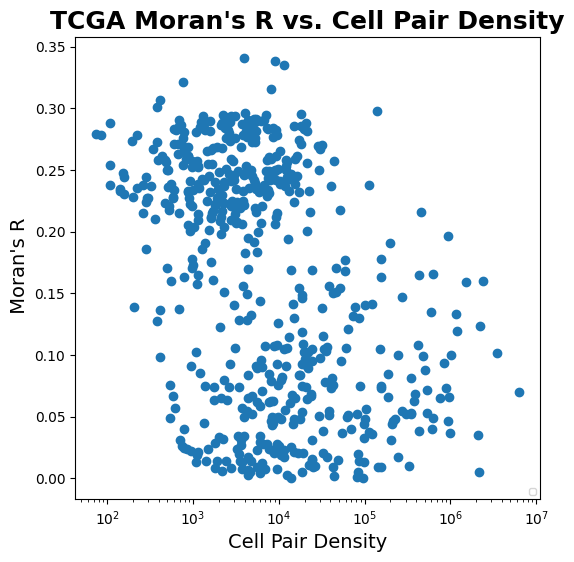

In [17]:
import matplotlib.pyplot as plt

# Filter out the points with y-values less than 0.0
filtered_df = average_df.query('R_val > 0.0')

label_list = filtered_df.index

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size

# 使用过滤后的数据绘制散点图，并为每个点添加名称
plt.scatter(x=filtered_df['abundance_product'], y=filtered_df['R_val'])

# Set the title and axis labels
plt.title("TCGA Moran's R vs. Cell Pair Density", fontsize=18, fontweight='bold')
plt.xlabel("Cell Pair Density", fontsize=14)
plt.ylabel(' Moran\'s R', fontsize=14)

# 设置X轴为对数坐标轴
plt.xscale('log')

# 显示图例
plt.legend(fontsize=6, loc='lower right')

# Show the plot
plt.show()

In [18]:
moran_list = filtered_df['R_val'].to_list()
density_list = filtered_df['abundance_product'].to_list()
label_list = filtered_df.index.to_list()

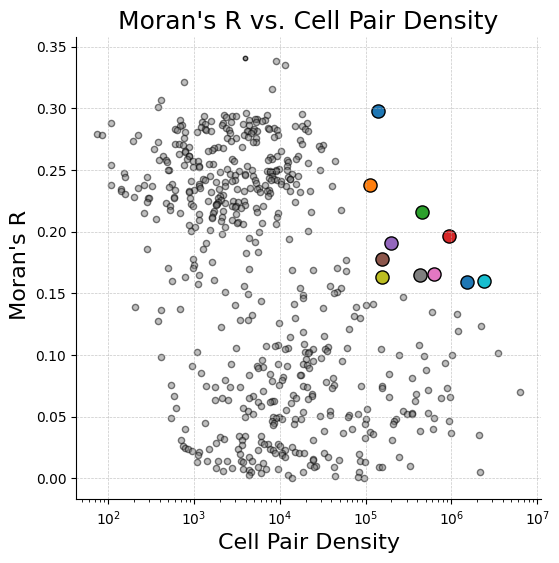

In [21]:
import matplotlib.pyplot as plt
import os


# Filter out the points with y-values less than 0.0
moran_list = filtered_df['R_val'].to_list()
density_list = filtered_df['abundance_product'].to_list()
label_list = filtered_df.index.to_list()

# 过滤moran小于0.0的点
filtered_data = [(density, moran, pair_name) for density, moran, pair_name in zip(density_list, moran_list, label_list) if moran > 0.0]

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size


label_list = []
# 使用过滤后的数据绘制散点图，并为每个点添加名称
other_label_added = False
for density, moran, pair_name in filtered_data:
    if moran > 0.15 and density > 1e5:
        plt.scatter(x=density, y=moran, label=pair_name, s=90, edgecolor='black')
        label_list.append(pair_name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=moran, label="other", c="grey", s=10, alpha=0.8, edgecolor='black')
            other_label_added = True
            label_list.append("other")
        else:
            plt.scatter(x=density, y=moran, c="grey", s=20, alpha=0.5, edgecolor='black')


# Set the title and axis labels
plt.title("Moran's R vs. Cell Pair Density", fontsize=18)
plt.xlabel("Cell Pair Density", fontsize=16)
plt.ylabel(' Moran\'s R', fontsize=16)

# 设置X轴为对数坐标轴
plt.xscale('log')

# Customize the grid and axis appearance
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 显示图例
# plt.legend(fontsize=6, loc='lower right')

# Set the color of x-axis and y-axis lines to black
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Remove the top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.savefig(os.path.join("brca_moransR_vs_cellpair_density.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

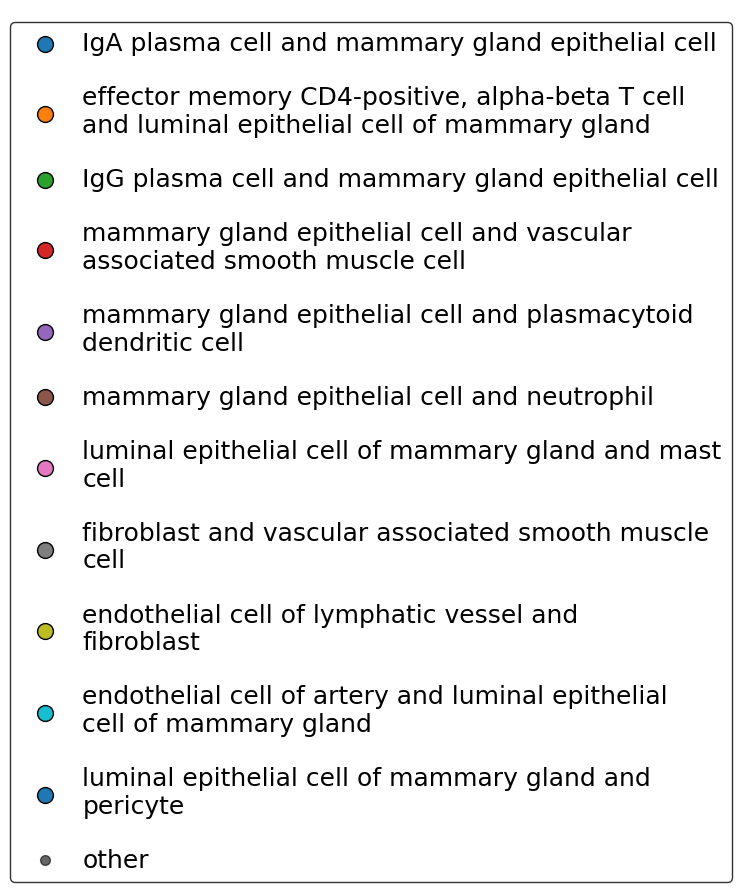

In [22]:
import textwrap

def wrap_labels(ax, width=40):
    """将图例标签换行的函数"""
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_legend().get_texts()]
    ax.legend(labels, loc="best", labelspacing=1.2, handletextpad=0.5, handlelength=2, fontsize=18, edgecolor='black')

# 然后创建并保存仅包含图例的图
fig_legend = plt.figure(figsize=(4, 5))
ax_legend = fig_legend.add_subplot(111)
# 使用同样的label和color创建一个空的散点图来生成图例
for label in label_list:
    if label == "other":
        continue
    ax_legend.scatter([], [], label=label, s=130, edgecolor='black')
ax_legend.scatter([], [], label="other", c="black", s=50, alpha=0.6, edgecolor='black')

# 生成图例
ax_legend.legend(fontsize=18, loc='center')
ax_legend.axis('off')

# 调用wrap_labels函数
wrap_labels(ax_legend, width=50)  # 可以调整width以适合您的需求

# Show the plot
plt.savefig("brca_moransR_vs_cellpair_density_legend.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close(fig_legend)

In [ ]:
# from tkinter import font
# import pandas as pd
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns


# df_figure = average_df[['A', 'B', 'R_val']]


# correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
# for var in correlation_df.index:
#     correlation_df.at[var, var] = 1
#     correlation_df = correlation_df.combine_first(correlation_df.T)
# correlation_df.iat[38, 38] = 1.0
# cell2location_cluster = sns.clustermap(correlation_df, figsize=(30, 30), cmap="viridis")
# cax = cell2location_cluster.ax_cbar
# cax.tick_params(labelsize=35)
# row_linkage = cell2location_cluster.dendrogram_row.linkage
# col_linkage = cell2location_cluster.dendrogram_col.linkage
# plt.savefig("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/brca_overall_Hist2Cell_clustermap_565cases.svg", bbox_inches='tight', pad_inches=0)
# plt.show()
# plt.close()